## Day 11: RNN (Recurrent Neural Networks)

* RNNs are neural networks that can remember past information, making them perfect for sequences like text, time series, and audio.

<h3> What we will learn? :</h3>

* What sequences are

* How RNNs work

* How to build RNN models in PyTorch

* How to train and use them for real tasks

<h3> RNN Architecture :</h3>

source: <a href="https://www.bing.com/images/search?view=detailV2&ccid=MOSKBcLc&id=F8D5F3102F63C19E60680A3795516683B83444C7&thid=OIP.MOSKBcLc3tMIjCZhhCYWdgHaCi&mediaurl=https%3a%2f%2fwww.simplilearn.com%2fice9%2ffree_resources_article_thumb%2fSimple_Recurrent_Neural_Network.png&exph=310&expw=904&q=rnn+architecture+in+deep+learning&FORM=IRPRST&ck=F32430EA47446AFDFA6FA09656C0E903&selectedIndex=7&itb=0"> Source of this image </a>

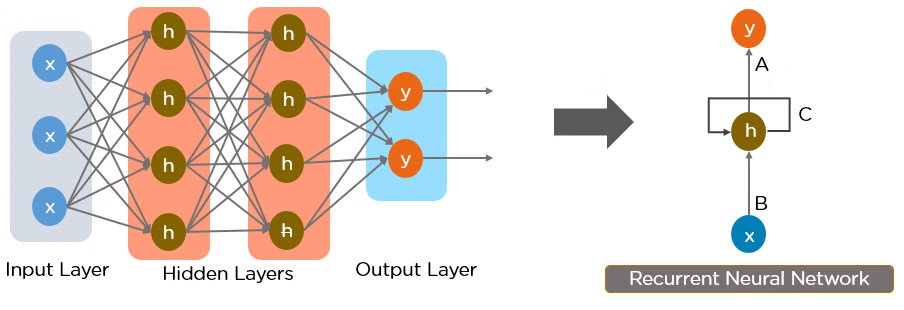

### Plan of work:

* Load Dataset (.csv)
* Vocab building and Embedding (`As our model won't understand the english words, we first need to build a vocab of unique words and provide index to each word. Post that these indexes will be embedded`)
* Build RNN Architecture
* Train
* Prediction

### Importing libraries:

In [2]:
import pandas as pd
import numpy as np
import torch
from pathlib import Path

### Step 1: Load Dataset (.CSV)

In [10]:
df=pd.read_csv('./data/100_Unique_QA_Dataset.csv')
df.head(3)

,question,answer
0,What is the capital of France?,Paris
1,What is the capital of Germany?,Berlin
2,Who wrote 'To Kill a Mockingbird'?,Harper-Lee


### Step 2: Vocab building and Embedding

In [12]:
#tokenize
def tokenize(text)->list:
    text=text.lower()
    text=text.replace("?","")
    text=text.replace("'","")
    return text.split()

In [13]:
#vocab building
vocab={'UNK':0}

In [27]:
def build_vocab(row):
    tokenized_question=tokenize(row['question'])
    tokenized_answer=tokenize(row['answer'])
    merged_tokens=tokenized_question+tokenized_answer
    for token in merged_tokens:
        if(token not in vocab):
            vocab[token]=len(vocab)
    

In [28]:
df.apply(build_vocab,axis=1)

0     None
1     None
2     None
3     None
4     None
      ... 
85    None
86    None
87    None
88    None
89    None
Length: 90, dtype: object

In [33]:
#creating indices
def text_to_indices(text,vocab):
    indexed_text=[]
    for token in tokenize(text):
        if(token in vocab):
            indexed_text.append(vocab[token])
        else:
            indexed_text.append(vocab['UNK'])
    return indexed_text

In [34]:
text_to_indices("What is Pytorch?",vocab=vocab)

[1, 2, 0]

In [36]:
from torch.utils.data import Dataset,DataLoader

In [38]:
class QADataset(Dataset):
    def __init__(self,df,vocab):
        super().__init__()
        self.df=df
        self.vocab=vocab
    def __len__(self):
        return self.df.shape[0]
    def __getitem__(self, index):
        numerical_question=text_to_indices(self.df.iloc[index]['question'],self.vocab)
        numerical_answer=text_to_indices(self.df.iloc[index]['answer'],vocab=self.vocab)
        return torch.tensor(numerical_question),torch.tensor(numerical_answer)

In [39]:
dataset=QADataset(df,vocab)

In [40]:
dataset[0]

(tensor([1, 2, 3, 4, 5, 6]), tensor([7]))

In [41]:
dataloader=DataLoader(dataset=dataset,batch_size=1,shuffle=True)

In [42]:
for question,answer in dataloader:
    print(question,answer)

tensor([[ 10,   2,  62,  63,   3, 283,   5, 284]]) tensor([[285]])
tensor([[  1,   2,   3,   4,   5, 135]]) tensor([[136]])
tensor([[ 1,  2,  3, 50, 51, 19,  3, 45]]) tensor([[52]])
tensor([[  1,   2,   3,   4,   5, 109]]) tensor([[317]])
tensor([[  1,  87, 229, 230, 231, 232]]) tensor([[233]])
tensor([[ 1,  2,  3, 69,  5, 53]]) tensor([[260]])
tensor([[ 42, 107,   2, 108,  19, 109]]) tensor([[110]])
tensor([[ 78,  79, 129,  81,  19,   3,  21,  22]]) tensor([[36]])
tensor([[ 1,  2,  3,  4,  5, 73]]) tensor([[74]])
tensor([[10,  2,  3, 66,  5, 67]]) tensor([[68]])
tensor([[  1,   2,   3, 221,   5, 222, 223, 224]]) tensor([[225]])
tensor([[ 42, 200,   2,  14, 201, 202, 203, 204]]) tensor([[205]])
tensor([[  1,   2,   3,  92, 137,  19,   3,  45]]) tensor([[185]])
tensor([[ 10,  75, 208]]) tensor([[209]])
tensor([[ 42, 216, 118, 217, 218,  19,  14, 219,  43]]) tensor([[220]])
tensor([[42, 18,  2, 62, 63,  3, 64, 18]]) tensor([[65]])
tensor([[ 10,  75, 111]]) tensor([[112]])
tensor([[  1,  

In [45]:
len(vocab)

324

### Step 3: RNN Arch. Buildiing

In [46]:
import torch.nn as nn

In [73]:
class SimpleRNN(nn.Module):
    def __init__(self,vocab_size):
        super().__init__()
        self.embedding=nn.Embedding(vocab_size,embedding_dim=50)
        self.rnn=nn.RNN(50,64,batch_first=True)
        self.fc=nn.Linear(64,vocab_size)
        
    def forward(self,question):
        embedded_question=self.embedding(question)
        hidden,final=self.rnn(embedded_question)
        output =self.fc(final.squeeze(0))
        
        return output

### Why don’t we use `nn.Sequential` for RNNs?

Because RNNs don’t work like normal feed-forward layers.

`nn.Sequential` assumes:

“Pass the whole input through layer1 → then layer2 → then layer3… in a straight line.”

But RNNs don’t operate in a straight line.
They operate step-by-step, one timestep at a time.

### Key Difference:
#### Feedforward (Sequential) models

* Input → Layer → Layer → Output

* One shot, no looping

* Perfect for nn.Sequential

#### RNNs

* Read input one word at a time

* Keep a hidden state (memory)

* Loop over timesteps

* Output depends on:

- current input

- previous hidden state

- Because of this loop + hidden state interaction, nn.Sequential cannot express the logic.

In [83]:
learning_rate=0.01
epochs=20

In [84]:
model=SimpleRNN(len(vocab))

In [85]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

### Step 4: Train Loop

In [86]:
#training loop
for epoch in range(epochs):
    total_loss=0
    for question,answer in dataloader:
        #clear the grads
        optimizer.zero_grad()
        #forward pass
        output=model(question)
        #calc. loss
        loss=criterion(output,answer[0])
        
        #calc. gradients
        loss.backward()
        #update the step
        optimizer.step()
        
        total_loss=total_loss+loss.item()
    print(f"Epoch:{epoch+1}: Loss-> {total_loss:4f}")

Epoch:1: Loss-> 542.693869
Epoch:2: Loss-> 354.872115
Epoch:3: Loss-> 151.881847
Epoch:4: Loss-> 70.328520
Epoch:5: Loss-> 28.167679
Epoch:6: Loss-> 27.283274
Epoch:7: Loss-> 26.271591
Epoch:8: Loss-> 17.070040
Epoch:9: Loss-> 15.728281
Epoch:10: Loss-> 12.854552
Epoch:11: Loss-> 10.197898
Epoch:12: Loss-> 5.606164
Epoch:13: Loss-> 11.055119
Epoch:14: Loss-> 6.949687
Epoch:15: Loss-> 9.690754
Epoch:16: Loss-> 4.992864
Epoch:17: Loss-> 7.014971
Epoch:18: Loss-> 4.350425
Epoch:19: Loss-> 6.198571
Epoch:20: Loss-> 7.506245


### Step 5: Predict

In [99]:
def predict(model,question,threshold=0.5):
    #convert question to numbers
    numerical_question=text_to_indices(question,vocab=vocab)
    #tensor
    question_tensor=torch.tensor(numerical_question).unsqueeze(0)
    #send to model
    output=model(question_tensor)
    #convert logits to probabilities
    probs=torch.nn.functional.softmax(output)
    #find max
    value,index=torch.max(probs,dim=1)
    if(value<threshold):
        return "I don't know"
    return list(vocab.keys())[index]

In [104]:
predict(model,"Who is the author of '1984'?")

C:\Users\asus\AppData\Local\Temp\ipykernel_14552\4166257477.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs=torch.nn.functional.softmax(output)


'george-orwell'